In [ ]:
!pip install pydicom opencv-python scikit-learn tensorflow matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 13.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
images_path="/content/drive/MyDrive" # Updated to point to the root of MyDrive
csv_path="/content/drive/MyDrive/csv file"

In [ ]:
import os
import cv2
import pydicom
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

In [ ]:
csv_path = "/content/drive/MyDrive/csv file/PD.csv" # Assuming PD.csv is the file you want to read
df = pd.read_csv(csv_path)

print("CSV shape:", df.shape)
print(df.head())

CSV shape: (100, 12)
  Image Data ID  Subject Group Sex  Age Visit Modality      Description  \
0     I10253274   110219    PD   M   74   V04      MRI       AX GRE -MT   
1     I10253253   105711    PD   M   64   V04      MRI  AXIAL 2D GRE-MT   
2     I10253235   101799    PD   M   64   V06      MRI  AXIAL 2D GRE-MT   
3      I1495912   101748    PD   F   63    BL      MRI     AX T2 GRE MT   
4      I1495907   101748    PD   F   63    BL      MRI     AX T2 GRE MT   

       Type    Acq Date Format Downloaded  
0  Original   6/14/2023    DCM  2/22/2026  
1  Original  10/05/2022    DCM  2/22/2026  
2  Original   6/20/2023    DCM  2/22/2026  
3  Original   7/07/2021    DCM  2/22/2026  
4  Original   7/07/2021    DCM  2/22/2026  


In [ ]:
csv_path = "/content/drive/MyDrive/csv file/Control.csv" # Assuming PD.csv is the file you want to read
df = pd.read_csv(csv_path)

print("CSV shape:", df.shape)
print(df.head())

CSV shape: (72, 12)
  Image Data ID  Subject    Group Sex  Age Visit Modality   Description  \
0     I10253524   130556  Control   M   73    BL      MRI     2D GRE-MT   
1     I10253528   130556  Control   M   73    BL      MRI     2D GRE-MT   
2      I1621894   157434  Control   F   60    BL      MRI     2D GRE-MT   
3      I1495888   101747  Control   M   62    BL      MRI  AX T2 GRE MT   
4      I1496364   101195  Control   M   74    BL      MRI     2D_GRE-MT   

       Type   Acq Date Format Downloaded  
0  Original  6/20/2023    DCM  2/22/2026  
1  Original  6/20/2023    DCM  2/22/2026  
2  Original  9/13/2022    DCM        NaN  
3  Original  7/07/2021    DCM        NaN  
4  Original  5/17/2021    DCM        NaN  


In [ ]:
print("\nCSV class distribution:")
print(df['Group'].value_counts())


CSV class distribution:
Group
Control    72
Name: count, dtype: int64


In [ ]:
def count_dicom_slices(folder_path):
    slice_count = 0

    for root, _, files in os.walk(folder_path):
        for file in files:
            if file.endswith(".dcm"):
                slice_count += 1

    return slice_count

In [ ]:
import zipfile

base_path = images_path # Corrected: Use the path to the dataset in Google Drive

# Define a map from actual folder names to the logical class names
folder_to_class_map = {
    "healthy": "Control",
    "unhealthy": "PD"
}
# Get the actual folder names to iterate over
actual_data_folders = list(folder_to_class_map.keys())


subject_slice_info = []

print(f"Contents of {base_path}:")
print(os.listdir(base_path))

# Extract zip files if they exist
for item in os.listdir(base_path):
    if item.endswith(".zip"):
        zip_path = os.path.join(base_path, item)
        extract_dir = os.path.join(base_path, os.path.splitext(item)[0].strip()) # Remove .zip and any trailing spaces
        if not os.path.exists(extract_dir):
            print(f"Extracting {zip_path} to {extract_dir}")
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(extract_dir)
        else:
            print(f"Directory {extract_dir} already exists, skipping extraction.")

# Now, list contents again to confirm extraction
print(f"Contents of {base_path} after extraction check:")
print(os.listdir(base_path))

# Iterate over the actual data folders
for folder_name in actual_data_folders:
    class_path = os.path.join(base_path, folder_name)
    logical_class_name = folder_to_class_map[folder_name]

    # Check if the class directory exists after extraction
    if not os.path.isdir(class_path):
        print(f"Warning: Class directory {class_path} not found. Skipping.")
        continue

    for subject in os.listdir(class_path):
        subject_path = os.path.join(class_path, subject)

        if os.path.isdir(subject_path):
            slices = count_dicom_slices(subject_path)

            subject_slice_info.append({
                "Subject": subject,
                "Class": logical_class_name,
                "Num_Slices": slices
            })


Contents of /content/drive/MyDrive:
['Colab Notebooks', 'csv file', 'dataset', 'healthy', 'unhealthy']
Contents of /content/drive/MyDrive after extraction check:
['Colab Notebooks', 'csv file', 'dataset', 'healthy', 'unhealthy']


In [ ]:
slice_df = pd.DataFrame(subject_slice_info)
slice_df.head()

,Subject,Class,Num_Slices
0,subject 4,Control,0
1,subject 5,Control,918
2,subject 1,PD,966
3,subject 2,PD,0


In [ ]:
print("\n🔹 Total MRI slices per class:")
print(slice_df.groupby("Class")["Num_Slices"].sum())


🔹 Total MRI slices per class:


KeyError: 'Class'

In [ ]:
print("\n🔹 Slice statistics per class:")
print(slice_df.groupby("Class")["Num_Slices"].describe())


🔹 Slice statistics per class:
         count    mean  std     min     25%     50%     75%     max
Class                                                              
Control    1.0  1905.0  NaN  1905.0  1905.0  1905.0  1905.0  1905.0
PD         1.0  2674.0  NaN  2674.0  2674.0  2674.0  2674.0  2674.0


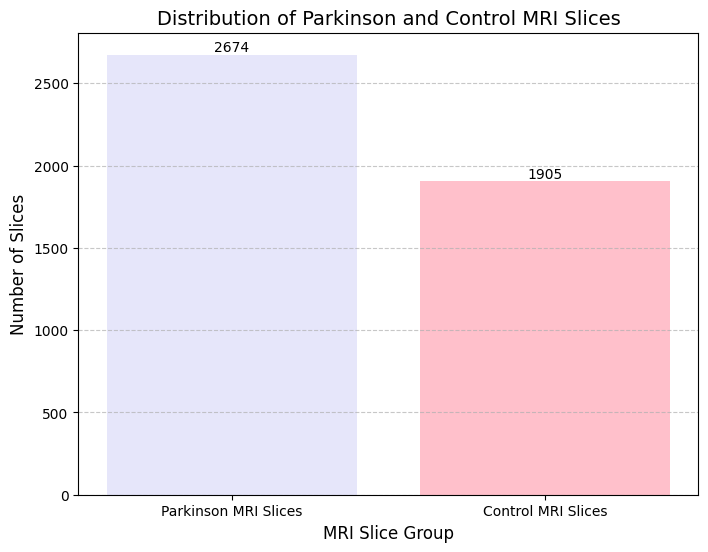

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract slice counts from slice_df
pd_slices = slice_df[slice_df['Class'] == 'PD']['Num_Slices'].sum()
control_slices = slice_df[slice_df['Class'] == 'Control']['Num_Slices'].sum()

# Data for plotting
data = {
    'Group': ['Parkinson MRI Slices', 'Control MRI Slices'],
    'Count': [pd_slices, control_slices]
}
df_slice_counts = pd.DataFrame(data)

# Create the bar plot
plt.figure(figsize=(8, 6))
plt.bar(
    df_slice_counts['Group'],
    df_slice_counts['Count'],
    color=['Lavender', 'Pink'] # Set custom colors
)

# Labels and title
plt.xlabel('MRI Slice Group', fontsize=12)
plt.ylabel('Number of Slices', fontsize=12)
plt.title('Distribution of Parkinson and Control MRI Slices', fontsize=14)

# Add count labels
for index, row in df_slice_counts.iterrows():
    plt.text(index, row['Count'], str(row['Count']),
             ha='center', va='bottom', fontsize=10)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

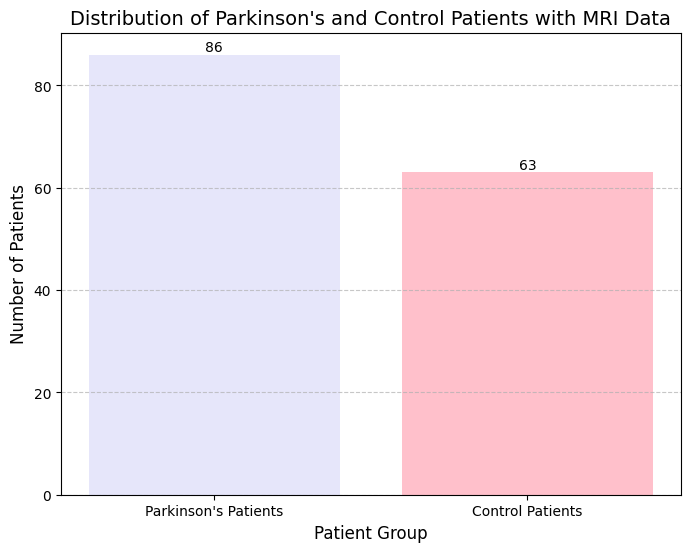

In [ ]:
import os

# Assuming the csv_path defined in cell qWqFJG360n1j refers to the folder
# We'll re-declare it as the directory to avoid conflicts from previous redefinitions
csv_folder_path = "/content/drive/MyDrive/csv file"

# Read the PD and Control CSVs to count unique subjects (patients)
pd_df = pd.read_csv(os.path.join(csv_folder_path, "PD.csv"))
control_df = pd.read_csv(os.path.join(csv_folder_path, "Control.csv"))

pd_count = pd_df['Subject'].nunique()
control_count = control_df['Subject'].nunique()

data = {
    'Group': ["Parkinson's Patients", 'Control Patients'],
    'Count': [pd_count, control_count]
}
df_patient_counts = pd.DataFrame(data)

plt.figure(figsize=(8, 6))
plt.bar(
    df_patient_counts['Group'],
    df_patient_counts['Count'],
    color=['lavender', 'pink'] # Set custom colors to brown and maroon
)

plt.xlabel('Patient Group', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.title("Distribution of Parkinson's and Control Patients with MRI Data", fontsize=14)

for index, row in df_patient_counts.iterrows():
    plt.text(index, row['Count'], str(row['Count']),
             ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
pd_df['Group'] = 'PD'
control_df['Group'] = 'Control'

labels_df = pd.concat([pd_df, control_df], ignore_index=True)

print("Combined DataFrame Head:")
print(labels_df.head())

print("\nCombined DataFrame Shape:")
print(labels_df.shape)

print("\nCombined DataFrame Group Distribution:")
print(labels_df['Group'].value_counts())

Combined DataFrame Head:
  Image Data ID  Subject Group Sex  Age Visit Modality      Description  \
0     I10253274   110219    PD   M   74   V04      MRI       AX GRE -MT   
1     I10253253   105711    PD   M   64   V04      MRI  AXIAL 2D GRE-MT   
2     I10253235   101799    PD   M   64   V06      MRI  AXIAL 2D GRE-MT   
3      I1495912   101748    PD   F   63    BL      MRI     AX T2 GRE MT   
4      I1495907   101748    PD   F   63    BL      MRI     AX T2 GRE MT   

       Type    Acq Date Format Downloaded  
0  Original   6/14/2023    DCM  2/22/2026  
1  Original  10/05/2022    DCM  2/22/2026  
2  Original   6/20/2023    DCM  2/22/2026  
3  Original   7/07/2021    DCM  2/22/2026  
4  Original   7/07/2021    DCM  2/22/2026  

Combined DataFrame Shape:
(172, 12)

Combined DataFrame Group Distribution:
Group
PD         100
Control     72
Name: count, dtype: int64


In [ ]:
IMG_SIZE = 224 # Define IMG_SIZE

def preprocess_dicom(dicom_path, img_size=IMG_SIZE):
    dcm = pydicom.dcmread(dicom_path)
    img = dcm.pixel_array.astype(np.float32)

    # Resize
    img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_AREA)

    # Min-max normalization
    min_val, max_val = img.min(), img.max()
    if max_val > min_val:
        img = (img - min_val) / (max_val - min_val)
    else:
        img = np.zeros_like(img)

    return img

In [ ]:
def preprocess_dicom_safe(path, img_size=224):
    try:
        # Read DICOM with force=True to handle non-compliant files
        dcm = pydicom.dcmread(path, force=True)

        # Check if Pixel Data exists
        if 'PixelData' not in dcm:
            print(f"Warning: '{path}' missing PixelData. Skipping.")
            return None

        img = dcm.pixel_array.astype(np.float32)

        # Convert multi-channel (if any) to 2D grayscale by averaging along the last axis
        if img.ndim == 3:
            # If it's a color image (H, W, 3) convert to grayscale (H, W)
            if img.shape[-1] == 3:
                img = np.mean(img, axis=-1)
            # If it's a 3D volume (D, H, W) or (H, W, D), take the middle slice or average
            elif img.shape[0] > 3 and img.shape[2] > 3: # Assuming depth is first or last if not color
                # This is a heuristic. A more robust solution would inspect DICOM tags.
                img = img[img.shape[0] // 2] # Take middle slice if it's a volume
            else:
                print(f"Warning: Unexpected 3D image shape {img.shape} for '{path}'. Skipping.")
                return None

        # Min–max normalization
        min_val = np.min(img)
        max_val = np.max(img)
        if max_val > min_val:
            img = (img - min_val) / (max_val - min_val)
        else:
            # Handle cases where all pixel values are the same (e.g., solid black image)
            img = np.zeros_like(img)

        # Resize
        img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_AREA)

        # Convert grayscale → 3-channel (H, W, 3) for model input (if needed, otherwise keep 1-channel)
        # For our current model, we need 1-channel input (224, 224, 1), so this step might be changed later.
        # For now, let's ensure it's 3-channel for consistency if the model expects it, and convert to 1-channel during data preparation for the model.
        # Given the `dbd6b0a8` cell converts X to 1-channel, it's safer to output 3-channel here and let the later step handle it.
        img = np.stack([img, img, img], axis=-1) # This makes it (IMG_SIZE, IMG_SIZE, 3)

        return img
    except Exception as e:
        # print(f"Error processing DICOM '{path}': {e}")
        return None

In [ ]:
# Re-construct an example subject folder path within the PD class
example_subject_folder = os.path.join(images_path, 'PD', 'PPMI')

# Initialize sample_dicom_path
sample_dicom_path = None

# Check if the example folder exists and find a DICOM file
if os.path.isdir(example_subject_folder):
    print(f"Contents of example subject folder: {example_subject_folder}")
    # Recursively search for a .dcm file
    for root, _, files in os.walk(example_subject_folder):
        for file in files:
            if file.lower().endswith(".dcm"):
                sample_dicom_path = os.path.join(root, file)
                print(f"Found a sample DICOM file: {sample_dicom_path}")
                break
        if sample_dicom_path:
            break

if not sample_dicom_path:
    print("Warning: No sample DICOM file could be found. Please ensure your dataset is correctly structured and contains .dcm files.")
else:
    # Now, run the original cell to test preprocess_dicom_safe
    img = preprocess_dicom_safe(sample_dicom_path)

    print(f"\nImage shape after preprocessing: {img.shape}")
    print(f"Image min and max values after preprocessing: {img.min()}, {img.max()}")

Contents of example subject folder: /content/drive/MyDrive/dataset/PD/PPMI
Found a sample DICOM file: /content/drive/MyDrive/dataset/PD/PPMI/3203/AX_T1_SE_C+/2011-01-06_12_34_23.0/I224190/PPMI_3203_MR_AX_T1_SE_C+__br_raw_20110318132515792_162_S101872_I224190.dcm

Image shape after preprocessing: (224, 224, 3)
Image min and max values after preprocessing: 0.0, 0.879581868648529


In [ ]:
img = preprocess_dicom_safe(sample_dicom_path)

print(img.shape)   # (224, 224, 3)
print(img.min(), img.max())  # 0.0 – 1.0

(224, 224, 3)
0.0 0.87958187


In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image # For Image.fromarray

class ParkinsonDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        subject_path = self.df.iloc[idx]["path"]
        label = self.df.iloc[idx]["label"]

        slices = []
        for file in sorted(os.listdir(subject_path)):
            if file.endswith(".dcm"):
                dcm = pydicom.dcmread(os.path.join(subject_path, file))
                img = dcm.pixel_array.astype(np.float32)
                img = (img - img.min()) / (img.max() - img.min())
                slices.append(img)

        volume = np.stack(slices)
        mid_slice = volume[len(volume)//2]

        img = Image.fromarray((mid_slice * 255).astype(np.uint8)).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.float32)

In [ ]:
def build_model():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(224,224,1)),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(2, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
import os
import pydicom
import numpy as np
import cv2

# 1. Initialize empty lists and dictionary
X = []  # For preprocessed images
y = []  # For corresponding labels (Group)
groups = []  # For subject IDs
skipped_files = []  # For logging files/folders skipped during path mapping
failed_preprocessing = []  # For logging errors during image preprocessing
dicom_paths_map = {}  # To map Image Data ID to its full DICOM folder path

print("Starting DICOM data consolidation and preprocessing...")

# 2. Iterate through each row of the labels_df DataFrame to build a map of Image Data ID to its actual DICOM folder path
print("\nPhase 1: Building DICOM path map...")
for index, row in labels_df.iterrows():
    image_data_id = str(row['Image Data ID']) # Ensure it's a string for path matching
    subject_id = str(row['Subject']) # Ensure it's a string
    group_label = row['Group'] # This will be 'Control' or 'PD'

    # Map the group label from labels_df to the actual folder name on Drive
    actual_folder_name = GROUP_LABEL_TO_FOLDER_NAME_MAP.get(group_label, group_label)

    # Construct the subject_base_path where the Image Data ID folder is expected to be nested
    # The structure is assumed to be images_path/Actual_FolderName/PPMI/SubjectID/...
    subject_base_path = os.path.join(images_path, actual_folder_name, 'PPMI', subject_id)

    found_dicom_folder_path = None
    found_dcm_in_target_folder = False

    if not os.path.isdir(subject_base_path):
        skipped_files.append(f"Subject base path not found for Image Data ID: {image_data_id} (Group: {group_label}, Actual Folder: {actual_folder_name}, Subject: {subject_id}). Expected base path: {subject_base_path}")
        continue

    # Use os.walk() to recursively search within the subject_base_path for a directory that matches the Image Data ID.
    # The target folder name is the Image Data ID, and it should contain .dcm files.
    for root, dirs, files in os.walk(subject_base_path):
        if os.path.basename(root) == image_data_id:
            # Check if this folder contains any .dcm files
            dcm_files_in_folder = [f for f in os.listdir(root) if f.lower().endswith(".dcm")]
            if dcm_files_in_folder:
                found_dicom_folder_path = root
                found_dcm_in_target_folder = True
                break # Found the correct folder and verified it has DCMs, so break from os.walk

    if found_dicom_folder_path and found_dcm_in_target_folder:
        dicom_paths_map[image_data_id] = found_dicom_folder_path
    else:
        skipped_files.append(f"No valid DICOM folder named '{image_data_id}' with .dcm files found under {subject_base_path}")

print(f"DICOM path map built. Found {len(dicom_paths_map)} valid DICOM folders out of {len(labels_df)} entries.")
print(f"Skipped {len(skipped_files)} entries during path mapping phase.")

# 3. After building the dicom_paths_map, iterate through each row of labels_df again to preprocess the images
print("\nPhase 2: Preprocessing DICOM images...")
for index, row in labels_df.iterrows():
    image_data_id = str(row['Image Data ID'])
    group_label = row['Group']
    subject_id = str(row['Subject'])

    dicom_folder_path = dicom_paths_map.get(image_data_id)

    if not dicom_folder_path:
        # This entry was already logged as skipped during path mapping, so just continue
        continue

    try:
        # Find the first .dcm file in the folder (sorting ensures consistent selection)
        dcm_files = sorted([f for f in os.listdir(dicom_folder_path) if f.lower().endswith(".dcm")])
        if not dcm_files:
            failed_preprocessing.append(f"No .dcm files found in mapped folder for Image Data ID: {image_data_id} at {dicom_folder_path}. This should ideally not happen if path mapping was successful.")
            continue

        first_dcm_path = os.path.join(dicom_folder_path, dcm_files[0])

        # Call the preprocess_dicom_safe function
        processed_img = preprocess_dicom_safe(first_dcm_path, IMG_SIZE)

        # Validate the shape and append
        if processed_img.shape == (IMG_SIZE, IMG_SIZE, 3):
            X.append(processed_img)
            y.append(group_label)
            groups.append(subject_id)
        else:
            failed_preprocessing.append(f"Incorrect shape after preprocessing for Image Data ID: {image_data_id} from {first_dcm_path}. Expected {(IMG_SIZE, IMG_SIZE, 3)}, got {processed_img.shape}")

    except Exception as e:
        failed_preprocessing.append(f"Error processing Image Data ID: {image_data_id} from folder {dicom_folder_path}. Error: {e}")

print(f"Finished preprocessing phase. Successfully processed {len(X)} images.")
print(f"Failed to preprocess {len(failed_preprocessing)} images during this phase.")

# 4. Convert the X, y, and groups lists into NumPy arrays
X = np.array(X)
y = np.array(y)
groups = np.array(groups)

# 5. Print a summary of the preprocessing
print("\n--- Overall Preprocessing Summary ---")
print(f"Total images processed successfully: {len(X)}")
print(f"Final shape of X (preprocessed images): {X.shape}")
print(f"Final shape of y (labels): {y.shape}")
print(f"Final shape of groups (subject IDs): {groups.shape}")

print(f"\nTotal entries skipped during path mapping: {len(skipped_files)}")
if skipped_files:
    print("Sample of skipped files (first 5):")
    for i, item in enumerate(skipped_files[:5]):
        print(f"  {i+1}. {item}")
    if len(skipped_files) > 5:
        print(f"  ...and {len(skipped_files) - 5} more.")

print(f"\nTotal entries with failed preprocessing: {len(failed_preprocessing)}")
if failed_preprocessing:
    print("Sample of failed preprocessing entries (first 5):")
    for i, item in enumerate(failed_preprocessing[:5]):
        print(f"  {i+1}. {item}")
    if len(failed_preprocessing) > 5:
        print(f"  ...and {len(failed_preprocessing) - 5} more.")

print("\nFirst 5 processed image shapes (from X array):")
if len(X) > 0:
    for i in range(min(5, len(X))):
        print(f"  X[{i}].shape: {X[i].shape}")
else:
    print("  No images were processed.")

print("\nFirst 5 labels (from y array):")
if len(y) > 0:
    print(y[:min(5, len(y))])
else:
    print("  No labels were collected.")

print("\nFirst 5 subject groups (from groups array):")
if len(groups) > 0:
    print(groups[:min(5, len(groups))])
else:
    print("  No groups were collected.")

Starting DICOM data consolidation and preprocessing...

Phase 1: Building DICOM path map...
DICOM path map built. Found 115 valid DICOM folders out of 172 entries.
Skipped 57 entries during path mapping phase.

Phase 2: Preprocessing DICOM images...
Finished preprocessing phase. Successfully processed 115 images.
Failed to preprocess 0 images during this phase.

--- Overall Preprocessing Summary ---
Total images processed successfully: 115
Final shape of X (preprocessed images): (115, 224, 224, 3)
Final shape of y (labels): (115,)
Final shape of groups (subject IDs): (115,)

Total entries skipped during path mapping: 57
Sample of skipped files (first 5):
  1. Subject base path not found for Image Data ID: I10253274 (Group: PD, Subject: 110219). Expected base path: /content/drive/MyDrive/dataset/PD/PPMI/110219
  2. Subject base path not found for Image Data ID: I10253253 (Group: PD, Subject: 105711). Expected base path: /content/drive/MyDrive/dataset/PD/PPMI/105711
  3. No valid DICOM f

In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_cat = to_categorical(y_encoded, num_classes=2)

In [ ]:
print("Original X shape:", X.shape)

# 1. Convert X from 3-channel to 1-channel grayscale
X = np.mean(X, axis=-1, keepdims=True)

print("X shape after converting to 1-channel grayscale:", X.shape)

# 2. Encode the y labels into numerical labels
# Re-initialize LabelEncoder and fit_transform to ensure y_encoded contains numerical values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("First 5 original labels:", y[:5])
print("First 5 numerically encoded labels:", y_encoded[:5])

# 3. Convert the y_encoded numerical labels into one-hot encoded categorical format
y_categorical = to_categorical(y_encoded, num_classes=2)

print("First 5 one-hot encoded labels:", y_categorical[:5])

# 4. Define EPOCHS
EPOCHS = 10
print(f"EPOCHS set to: {EPOCHS}")

# 5. Define BATCH_SIZE
BATCH_SIZE = 32
print(f"BATCH_SIZE set to: {BATCH_SIZE}")

Original X shape: (115, 224, 224, 3)
X shape after converting to 1-channel grayscale: (115, 224, 224, 1)
First 5 original labels: ['PD' 'PD' 'PD' 'PD' 'PD']
First 5 numerically encoded labels: [1 1 1 1 1]
First 5 one-hot encoded labels: [[0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]
EPOCHS set to: 10
BATCH_SIZE set to: 32


In [ ]:
print("Starting K-Fold Cross-Validation...")

# 1. Initialize GroupKFold
gkf = GroupKFold(n_splits=5)
print(f"GroupKFold initialized with {gkf.n_splits} splits.")

# 2. Create an empty list to store training histories
histories = []

# 3. Loop through the folds
for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y_categorical, groups)):
    print(f"\n--- Fold {fold+1}/{gkf.n_splits} ---")

    # 4. Create training and validation data subsets
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y_categorical[train_idx], y_categorical[val_idx]

    print(f"Training data shape: {X_train.shape}, Labels shape: {y_train.shape}")
    print(f"Validation data shape: {X_val.shape}, Labels shape: {y_val.shape}")

    # 5. Build a new model for each fold
    model = build_model()
    print("Model built for current fold.")

    # 6. Train the model and store history
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val),
        verbose=1 # Set to 1 to show progress bar, 2 for one line per epoch
    )
    histories.append(history)
    print(f"Training for Fold {fold+1} completed. History stored.")

    # 7. Print training and validation accuracy for each epoch
    print(f"\nAccuracy for Fold {fold+1}:")
    for epoch_num in range(EPOCHS):
        print(f"Epoch {epoch_num+1}: Train Accuracy = {history.history['accuracy'][epoch_num]:.4f}, Validation Accuracy = {history.history['val_accuracy'][epoch_num]:.4f}")

print("\nAll K-Fold cross-validation runs completed.")

Starting K-Fold Cross-Validation...
GroupKFold initialized with 5 splits.

--- Fold 1/5 ---
Training data shape: (92, 224, 224, 1), Labels shape: (92, 2)
Validation data shape: (23, 224, 224, 1), Labels shape: (23, 2)
Model built for current fold.
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.6522 - loss: 0.6485 - val_accuracy: 0.8696 - val_loss: 0.4797
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.6848 - loss: 0.6003 - val_accuracy: 0.8696 - val_loss: 0.3923
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.6848 - loss: 0.6047 - val_accuracy: 0.8696 - val_loss: 0.3817
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.6848 - loss: 0.6250 - val_accuracy: 0.8696 - val_loss: 0.4140
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.6848 - loss: 0.5856 - val_accuracy: 0.8696 - val_loss: 0.4558
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.6848 - loss: 0.5901 - val_accuracy: 0.8696 - val_loss: 0.4832
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.6848 - loss: 0.5744 - val_accuracy: 0.9130 - val_loss: 0.4746
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.6848 - loss: 0.5693 - val_accuracy: 0.9130 - val_loss: 0.4321
Epoch 9/10


Now, let's save the trained model so it can be loaded later. We'll save the model that was trained in the *last* fold of the cross-validation.

In [ ]:
# Save the last trained model
model.save('cnn_parkinson_model.h5')
print("Model 'cnn_parkinson_model.h5' saved successfully.")

Model 'cnn_parkinson_model.h5' saved successfully.


As requested, let's list the files in the current directory to confirm that `cnn_parkinson_model.h5` has been saved.

In [ ]:
!ls -F

cnn_parkinson_model.h5	drive/	sample_data/



Visualizing training history for each fold...

--- Plotting History for Fold 1 ---


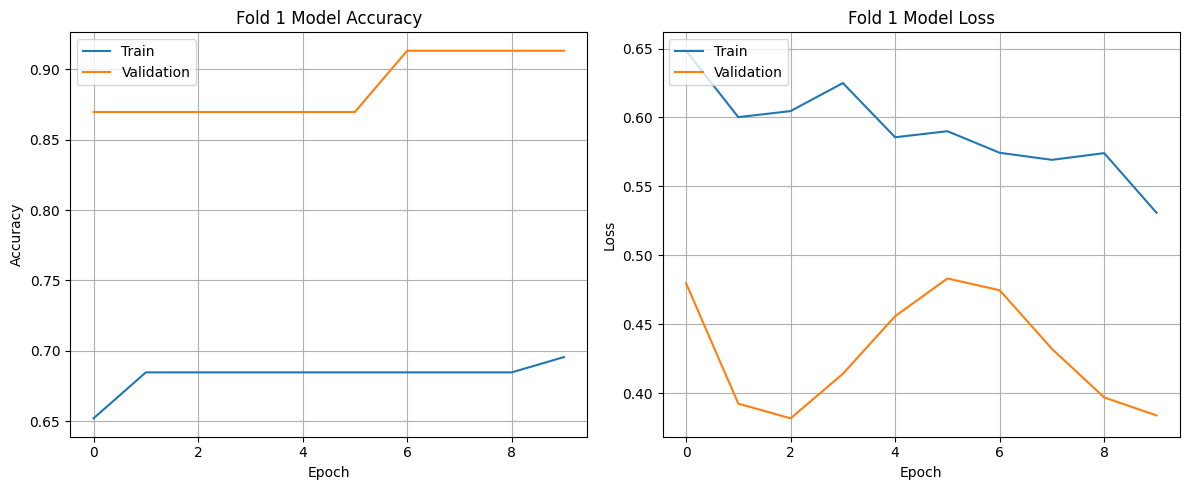


--- Plotting History for Fold 2 ---


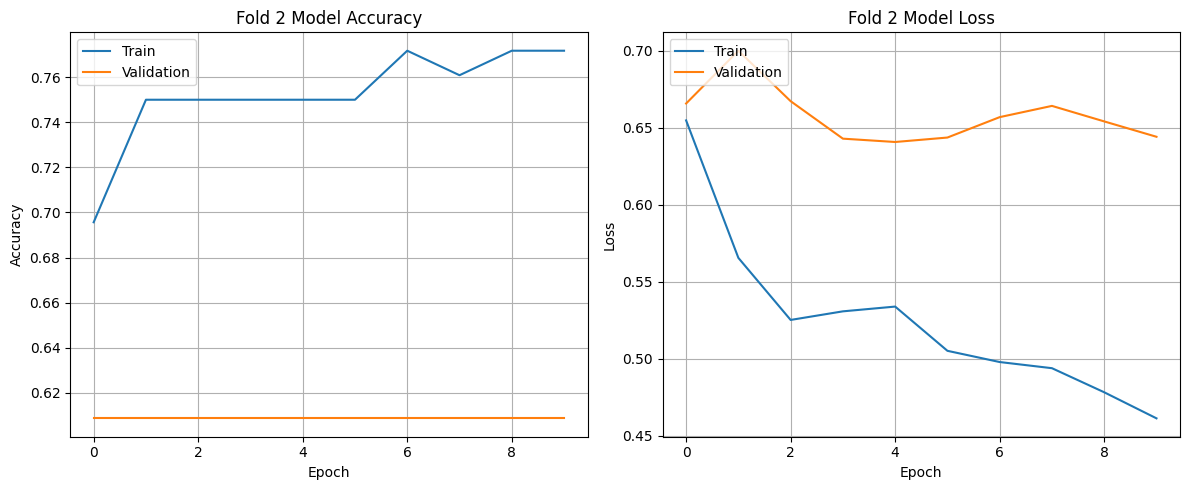


--- Plotting History for Fold 3 ---


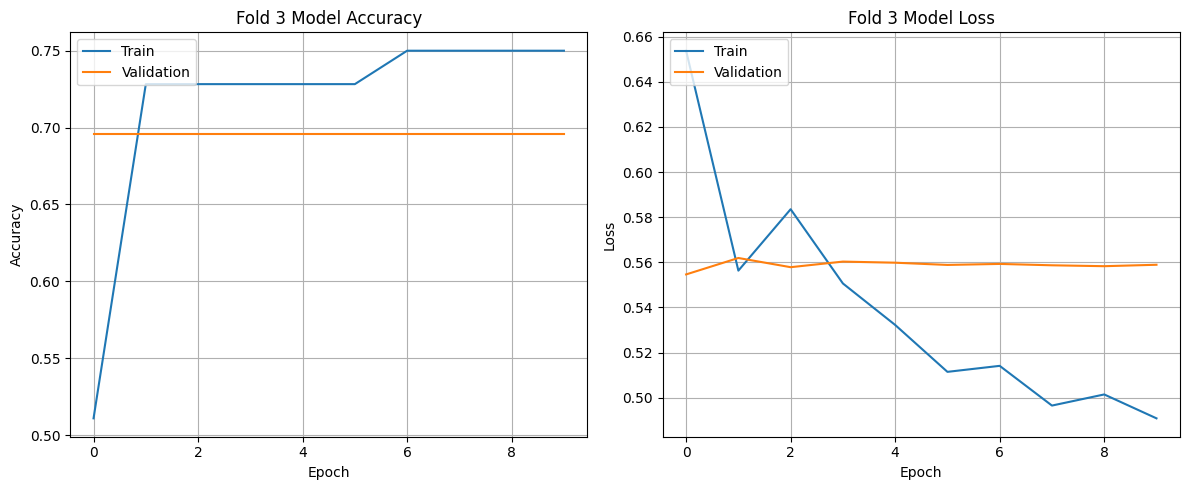


--- Plotting History for Fold 4 ---


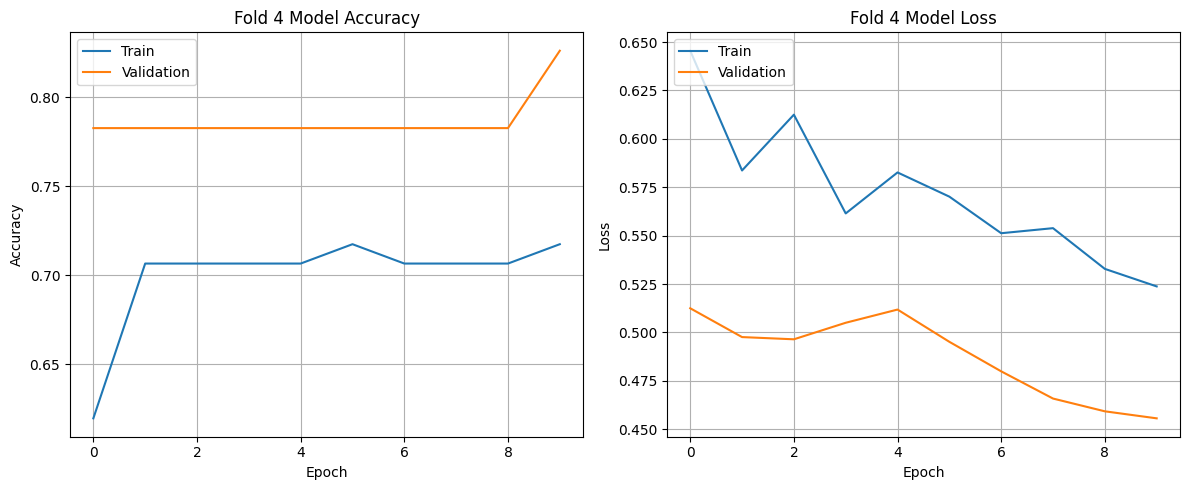


--- Plotting History for Fold 5 ---


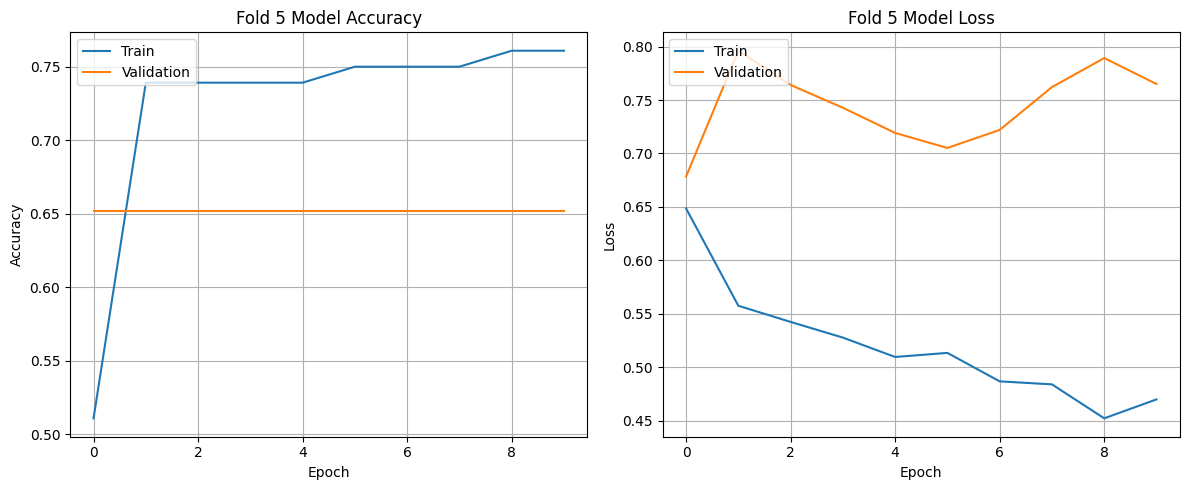


History visualizations completed for all folds.


In [ ]:
import matplotlib.pyplot as plt

# 8. Visualize training history for each fold
print("\nVisualizing training history for each fold...")
for i, history in enumerate(histories):
    print(f"\n--- Plotting History for Fold {i+1} ---")

    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'Fold {i+1} Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.grid(True)

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'Fold {i+1} Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

print("\nHistory visualizations completed for all folds.")

In [ ]:
print("\n--- Consolidated Metrics Across All Folds ---")

# 1. Initialize empty lists
all_train_accs = []
all_val_accs = []
all_train_losses = []
all_val_losses = []

# Check if histories is empty before proceeding
if not histories:
    print("Error: The 'histories' list is empty. Please run the K-Fold cross-validation cell (KAMa1iutesAb) first to populate 'histories'.")
else:
    # 2. Iterate through each history object and append metrics
    for history in histories:
        all_train_accs.append(history.history['accuracy'])
        all_val_accs.append(history.history['val_accuracy'])
        all_train_losses.append(history.history['loss'])
        all_val_losses.append(history.history['val_loss'])

    # 3. Convert lists to NumPy arrays for easier calculation
    # The shape will be (num_folds, num_epochs)
    all_train_accs = np.array(all_train_accs)
    all_val_accs = np.array(all_val_accs)
    all_train_losses = np.array(all_train_losses)
    all_val_losses = np.array(all_val_losses)

    # 4. Calculate the average metrics across all folds for each epoch
    # We take the mean along axis 0 (across the folds)
    # Add a check to ensure arrays are not empty before calculating mean
    if all_train_accs.size > 0:
        mean_train_accs = np.mean(all_train_accs, axis=0)
        mean_val_accs = np.mean(all_val_accs, axis=0)
        mean_train_losses = np.mean(all_train_losses, axis=0)
        mean_val_losses = np.mean(all_val_losses, axis=0)
    else:
        print("Warning: No training history found. Cannot calculate average metrics.")
        # Initialize means as empty arrays to prevent further IndexErrors
        mean_train_accs = np.array([])
        mean_val_accs = np.array([])
        mean_train_losses = np.array([])
        mean_val_losses = np.array([])

    # 5. Print the calculated average metrics
    print("\nAverage Training and Validation Metrics per Epoch (Across All Folds):")
    if mean_train_accs.size > 0:
        for epoch in range(EPOCHS):
            print(f"Epoch {epoch + 1}:")
            print(f"  Avg Train Acc: {mean_train_accs[epoch]:.4f}, Avg Val Acc: {mean_val_accs[epoch]:.4f}")
            print(f"  Avg Train Loss: {mean_train_losses[epoch]:.4f}, Avg Val Loss: {mean_val_losses[epoch]:.4f}")
    else:
        print("  No average metrics to display.")



--- Consolidated Metrics Across All Folds ---

Average Training and Validation Metrics per Epoch (Across All Folds):
Epoch 1:
  Avg Train Acc: 0.5978, Avg Val Acc: 0.7217
  Avg Train Loss: 0.6502, Avg Val Loss: 0.5782
Epoch 2:
  Avg Train Acc: 0.7217, Avg Val Acc: 0.7217
  Avg Train Loss: 0.5726, Avg Val Loss: 0.5896
Epoch 3:
  Avg Train Acc: 0.7217, Avg Val Acc: 0.7217
  Avg Train Loss: 0.5736, Avg Val Loss: 0.5734
Epoch 4:
  Avg Train Acc: 0.7217, Avg Val Acc: 0.7217
  Avg Train Loss: 0.5591, Avg Val Loss: 0.5730
Epoch 5:
  Avg Train Acc: 0.7217, Avg Val Acc: 0.7217
  Avg Train Loss: 0.5488, Avg Val Loss: 0.5775
Epoch 6:
  Avg Train Acc: 0.7261, Avg Val Acc: 0.7217
  Avg Train Loss: 0.5380, Avg Val Loss: 0.5772
Epoch 7:
  Avg Train Acc: 0.7326, Avg Val Acc: 0.7304
  Avg Train Loss: 0.5249, Avg Val Loss: 0.5785
Epoch 8:
  Avg Train Acc: 0.7304, Avg Val Acc: 0.7304
  Avg Train Loss: 0.5195, Avg Val Loss: 0.5765
Epoch 9:
  Avg Train Acc: 0.7348, Avg Val Acc: 0.7304
  Avg Train Loss: 0.

In [ ]:
print("\n--- Overall Average Metrics ---")
print(f"Overall Average Training Accuracy (last epoch): {mean_train_accs[-1]*100:.2f}%")
print(f"Overall Average Validation Accuracy (last epoch): {mean_val_accs[-1]*100:.2f}%")


--- Overall Average Metrics ---
Overall Average Training Accuracy (last epoch): 73.91%
Overall Average Validation Accuracy (last epoch): 73.91%


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# IMPORT LIBRARIES
# =========================================================

import os
import cv2
import pydicom
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

ModuleNotFoundError: No module named 'pydicom'

In [ ]:
# =========================================================
# LOAD TRAINED CNN MODEL
# =========================================================

model = load_model('/content/cnn_parkinson_model.h5')

In [ ]:
# =========================================================
# SETTINGS
# =========================================================

IMG_SIZE = 224

# Update healthy_path and unhealthy_path to point to the correct dataset folders
# Based on the user's request and the likely structure containing a 'PPMI' subfolder
healthy_path = os.path.join(images_path, 'healthy', 'PPMI')
unhealthy_path = os.path.join(images_path, 'unhealthy', 'PPMI')

classes = ['Healthy', 'Unhealthy']

# Define the GROUP_LABEL_TO_FOLDER_NAME_MAP to ensure consistency with actual folder names
# Map 'Control' from labels_df to the 'healthy' folder, and 'PD' to the 'unhealthy' folder.
GROUP_LABEL_TO_FOLDER_NAME_MAP = {
    'Control': 'healthy',
    'PD': 'unhealthy'
}

In [ ]:
# =========================================================
# STORE DATA
# =========================================================

X_test = []

y_test = []

patient_results = {}

In [ ]:
# =========================================================
# FUNCTION TO PROCESS MRI FILES
# =========================================================

def process_subject(subject_path, label, mode):

    patient_images = []

    files = sorted(os.listdir(subject_path))

    selected_files = [] # Initialize selected_files here

    # =====================================================
    # SUBJECT 1
    # USE IMG-0003 FILES ONLY
    # =====================================================

    if mode == 'subject1':

        for file in files:

            if file.startswith('IMG-0003') and file.endswith('.dcm'):

                selected_files.append(file)
                 # =====================================================
    # SUBJECT 5
    # USE IMG-0001 FILES ONLY
    # =====================================================

    elif mode == 'subject5':

        for file in files:

            if file.startswith('IMG-0001'):

                selected_files.append(file)

    # =====================================================
    # SUBJECT 2 / SUBJECT 4
    # USE ALL FILES
    # =====================================================

    else:

        for file in files:

            if (file.endswith('.dcm') or
                file.endswith('.ima') or
                file.endswith('.IMA')):

                selected_files.append(file)

    # =====================================================
    # READ MRI FILES
    # =====================================================

    for file_name in selected_files:

        file_path = os.path.join(subject_path, file_name)

        try:

            # =================================================
            # READ DICOM / IMA
            # =================================================

            dicom = pydicom.dcmread(file_path, force=True)

            img = dicom.pixel_array
            # =================================================
            # RESIZE
            # =================================================

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            # =================================================
            # NORMALIZE
            # =================================================

            img = img.astype(np.float32)

            img = (img - np.min(img)) / (np.max(img) - np.min(img))
              # =================================================
            # CNN INPUT SHAPE
            # =================================================

            img = np.expand_dims(img, axis=-1)

            patient_images.append(img)

            X_test.append(img)

            y_test.append(label)

        except:

            print(f"Could not read: {file_name}")

    return np.array(patient_images)

In [ ]:
print('Contents of /content/drive/MyDrive:')
!ls -F /content/drive/MyDrive

Contents of /content/drive/MyDrive:
'Colab Notebooks'/  'csv file'/   dataset/   healthy/   unhealthy/
